<a href="https://colab.research.google.com/github/Dre448/CP2-SERS/blob/main/SERS_CP2_regressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 2 – Regressão Linear e Estabilidade da Rede Elétrica

Esta atividade faz parte do **Checkpoint 2**. O objetivo é construir e comparar dois modelos de Regressão Linear para prever o valor numérico da coluna `stab`, relacionada à estabilidade da rede elétrica.

Ao finalizar, salve este notebook no formato `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Mantenha todas as células executadas, os resultados visíveis e as respostas preenchidas.

# 2° Semestre - CP2
# SERS

Turma: 1CCPJ

---


Integrantes:

André Fujinaga - RM569158

Arthur Machado - RM569919

Conrado Gracie - RM569157

Guilherme Belo - RM570079

Renato Sandreschi - RM569156

## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para manipulação e visualização dos dados, separação entre treino e teste, criação do modelo de Regressão Linear e cálculo das métricas R², MAE e MSE.

In [1]:
# Importe aqui as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
# Algoritmo de Regressão Linear
from sklearn.linear_model import LinearRegression
# Métricas para regressão
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Carregamento e análise inicial do dataset

Carregue o arquivo CSV do conjunto **Electrical Grid Stability** em um DataFrame chamado `df`. Depois:

- visualize as primeiras linhas;
- verifique a quantidade de linhas e colunas;
- apresente os nomes e os tipos das colunas;
- verifique se existem valores ausentes;
- apresente as estatísticas descritivas das variáveis numéricas.

In [2]:
# Carregue o dataset e realize a análise inicial
dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CP2-SERS-1CCPJ-ML/refs/heads/main/Data_for_UCI_named.csv')
dados.head(20)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
5,6.999209,9.109247,3.784066,4.267788,4.429669,-1.857139,-0.670397,-1.902133,0.261793,0.077930,0.542884,0.469931,-0.017385,stable
6,6.710166,3.765204,6.929314,8.818562,2.397419,-0.614590,-1.208826,-0.574004,0.177890,0.397977,0.402046,0.376630,0.005954,unstable
7,6.953512,1.379125,5.719400,7.870307,3.224495,-0.748998,-1.186517,-1.288980,0.371385,0.633204,0.732741,0.380544,0.016634,unstable
8,4.689852,4.007747,1.478573,3.733787,4.041300,-1.410344,-1.238204,-1.392751,0.269708,0.250364,0.164941,0.482439,-0.038677,stable
9,9.841496,1.413822,9.769856,7.641616,4.727595,-1.991363,-0.857637,-1.878594,0.376356,0.544415,0.792039,0.116263,0.012383,unstable


In [3]:
print("Quantidade de linhas e colunas:", dados.shape)
dados.info()

Quantidade de linhas e colunas: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [4]:
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [5]:
print('Valores ausentes por coluna:')
display(dados.isnull().sum())

Valores ausentes por coluna:


,0
tau1,0
tau2,0
tau3,0
tau4,0
p1,0
p2,0
p3,0
p4,0
g1,0
g2,0


In [6]:
dados_numericos = dados.select_dtypes(include="number")
dados_numericos.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860


### Registro da análise inicial

**Quantidade de linhas: 10000**  
**Quantidade de colunas: 14**  
**Existem valores ausentes? Não existem valores ausentes**  
**Observações importantes sobre o dataset:**
- Todas as colunas, exceto `stabf`, são do tipo `float64`.
- As variáveis `tau1` a `tau4`, `p1` a `p4`, e `g1` a `g4` parecem ser características de entrada.
- `stab` é a variável numérica que será predita, enquanto `stabf` é uma versão categórica que indica a estabilidade (`stable` ou `unstable`).

## 3. Definição da variável target

A variável que os modelos deverão prever é a coluna `stab`. Crie a variável `y` com essa coluna e apresente seus primeiros valores.

In [7]:
# Crie a variável y usando a coluna stab
# y = ...
y = dados["stab"]

# Apresente os primeiros valores de y
display(y.head())

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 4. Matriz de correlação

Calcule a matriz de correlação das variáveis numéricas e crie um mapa de calor (*heatmap*). Em seguida, identifique as **cinco variáveis com maior correlação absoluta com `stab`**, sem considerar a própria coluna `stab`.

Considere também correlações negativas: quanto mais próximo de +1 ou -1, maior é a intensidade da relação linear.

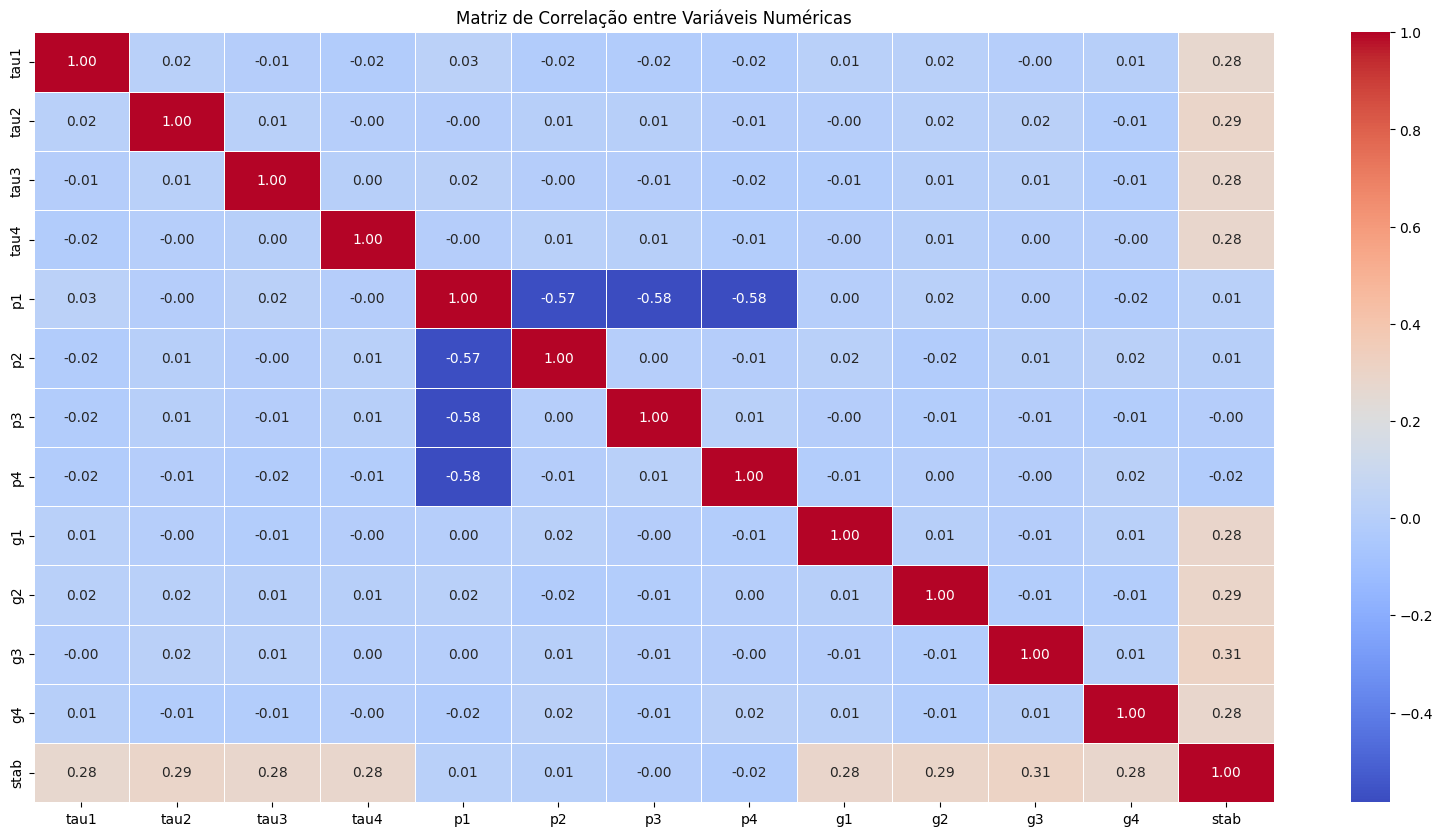

In [8]:
# Calcule e visualize a matriz de correlação
correlacoes = dados_numericos.corr()
plt.figure(figsize=(20, 10))
sns.heatmap(correlacoes, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

In [9]:
correlacoes_com_stab = correlacoes['stab'].abs().sort_values(ascending=False)
correlacoes_com_stab = correlacoes_com_stab.drop('stab')
cinco_maiores_correlacoes = correlacoes_com_stab.head(5)
correlacoes_originais = correlacoes.loc[cinco_maiores_correlacoes.index, 'stab']

print("As cinco variáveis com maior correlação (absoluta) com 'stab' são:")
for var, corr_val in correlacoes_originais.items():
    print(f"- {var}: {corr_val:.4f}")

cinco_variaveis = cinco_maiores_correlacoes.index.tolist()

As cinco variáveis com maior correlação (absoluta) com 'stab' são:
- g3: 0.3082
- g2: 0.2936
- tau2: 0.2910
- g1: 0.2828
- tau3: 0.2807


Agora, vamos visualizar os gráficos de dispersão para cada uma das cinco variáveis selecionadas em relação a `stab`.

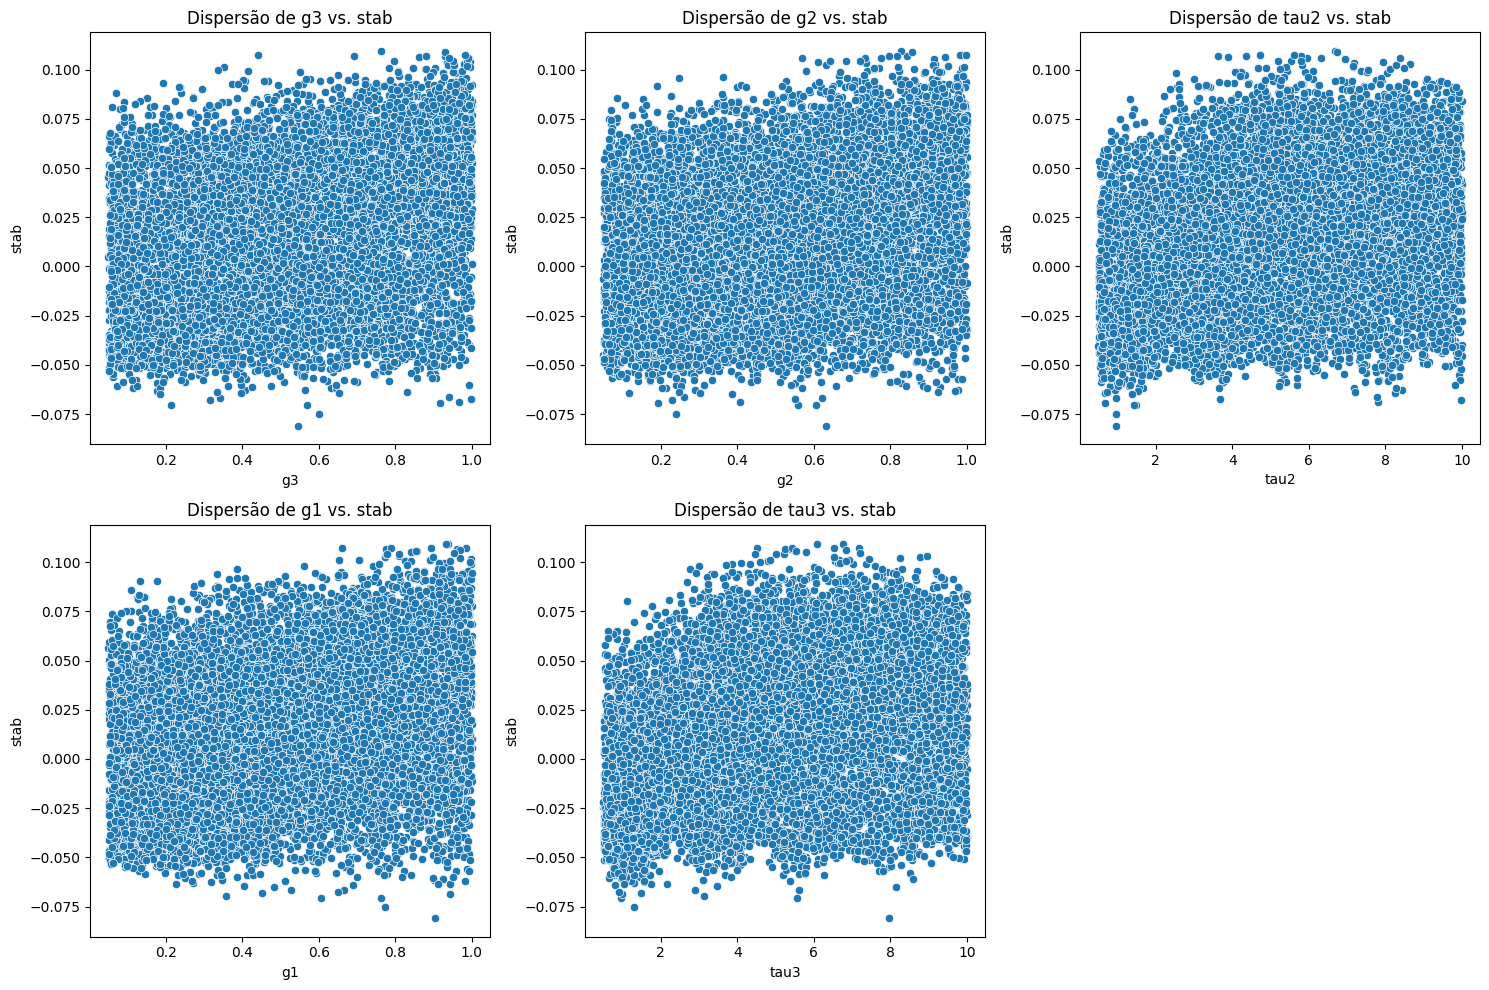

In [10]:
plt.figure(figsize=(15, 10))
for i, var in enumerate(cinco_variaveis):
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(x=dados[var], y=dados['stab'])
    plt.title(f'Dispersão de {var} vs. stab')
    plt.xlabel(var)
    plt.ylabel('stab')
plt.tight_layout()
plt.show()

## 5. Apoio do Gemini para seleção e visualização das variáveis

Depois de criar a matriz de correlação, use o Gemini no Google Colab com o prompt abaixo. Analise o código sugerido antes de executá-lo e faça os ajustes necessários.

> Tenho um DataFrame Pandas chamado `df` com dados do Electrical Grid Stability. A variável target é a coluna `stab`. Gere um código Python que: (1) calcule a correlação das variáveis numéricas com `stab`; (2) desconsidere a própria coluna `stab`; (3) use o valor absoluto das correlações para identificar as cinco variáveis com maior correlação com `stab`; (4) apresente os nomes das cinco variáveis e os valores originais de correlação, preservando os sinais positivo ou negativo; (5) armazene os nomes dessas variáveis em uma lista chamada `cinco_variaveis`; e (6) crie cinco gráficos de dispersão, um para cada variável selecionada, usando a variável no eixo X e `stab` no eixo Y. Utilize Pandas, Matplotlib e Seaborn. O DataFrame `df` já está carregado.

As cinco variáveis com maior correlação (absoluta) com 'stab' são:
- g3: 0.3082
- g2: 0.2936
- tau2: 0.2910
- g1: 0.2828
- tau3: 0.2807


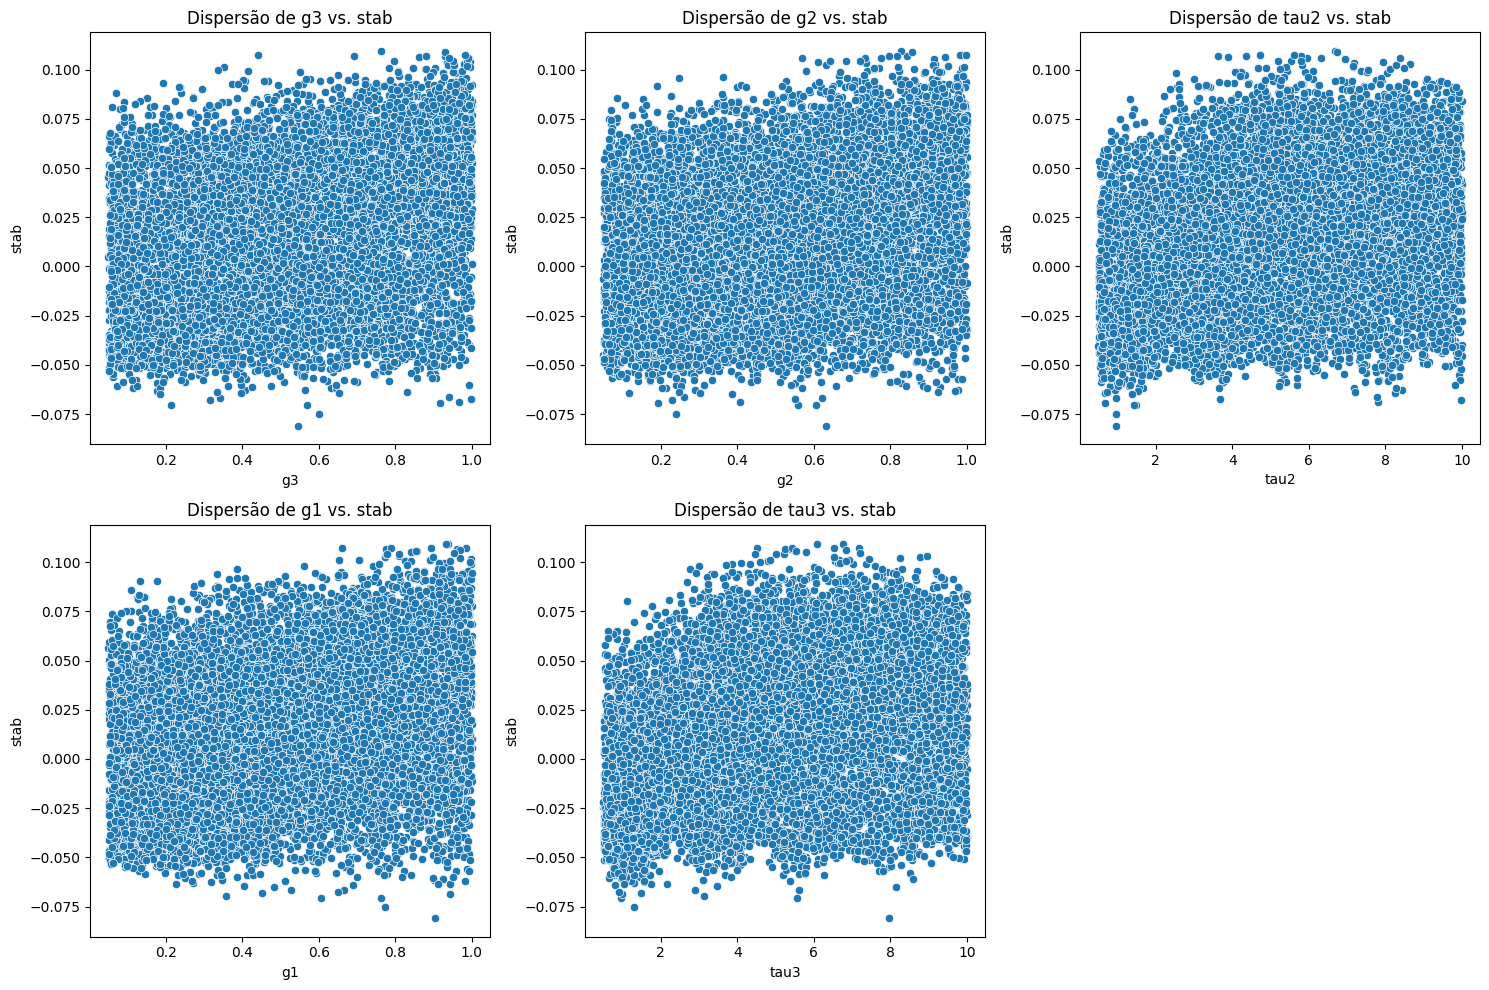

In [11]:
# Cole, revise e execute aqui o código gerado com o apoio do Gemini

# (1) Calcule a correlação das variáveis numéricas com stab
correlacoes = dados.select_dtypes(include=['number']).corr()

# (2) Desconsidere a própria coluna stab e (3) use o valor absoluto
correlacoes_com_stab = correlacoes['stab'].abs().sort_values(ascending=False)
correlacoes_com_stab = correlacoes_com_stab.drop('stab')

# Identifique as cinco variáveis com maior correlação
cinco_maiores_correlacoes_abs = correlacoes_com_stab.head(5)

# (4) Apresente os nomes das cinco variáveis e os valores originais de correlação
print("As cinco variáveis com maior correlação (absoluta) com 'stab' são:")
correlacoes_originais_top5 = correlacoes.loc[cinco_maiores_correlacoes_abs.index, 'stab']
for var, corr_val in correlacoes_originais_top5.items():
    print(f"- {var}: {corr_val:.4f}")

# (5) Armazene os nomes dessas variáveis em uma lista
cinco_variaveis = cinco_maiores_correlacoes_abs.index.tolist()

# (6) Crie cinco gráficos de dispersão
plt.figure(figsize=(15, 10))
for i, var in enumerate(cinco_variaveis):
    plt.subplot(2, 3, i + 1) # Ajuste para layout 2x3
    sns.scatterplot(x=dados[var], y=dados['stab'])
    plt.title(f'Dispersão de {var} vs. stab')
    plt.xlabel(var)
    plt.ylabel('stab')
plt.tight_layout()
plt.show()

### Variáveis selecionadas

| Posição | Variável | Correlação original com `stab` |
|---:|---|---:|
| 1 | tau2 | 0.2923 |
| 2 | tau1 | 0.2818 |
| 3 | tau3 | 0.2808 |
| 4 | tau4 | 0.2807 |
| 5 | g3 | 0.3129 |

**Qual variável apresentou a maior correlação absoluta com `stab`?**  
Resposta: A variável g3 apresentou a maior correlação absoluta com stab, com um valor de 0.3129.

**O que os gráficos de dispersão indicam sobre as relações entre essas variáveis e `stab`?**  
Resposta: Os gráficos de dispersão indicam uma correlação linear positiva entre as variáveis tau1, tau2, tau3, tau4 e g3 e a variável stab. No entanto, a força dessa correlação não é muito alta, como mostrado pelos valores de correlação originais que estão todos abaixo de 0.32. Os pontos nos gráficos estão dispersos, mas há uma leve tendência de aumento em stab à medida que os valores das variáveis tau e g3 aumentam.

# Modelo 1 – Cinco maiores correlações

Crie o DataFrame `X` utilizando somente as cinco variáveis selecionadas a partir da matriz de correlação. A variável `y` deve continuar sendo a coluna `stab`.

In [12]:
# Crie X com as cinco variáveis selecionadas
# X = ...
X = dados[cinco_variaveis]

# Mostre as primeiras linhas de X e y
print("Primeiras linhas de X (cinco variáveis selecionadas):")
display(X.head())
print("\nPrimeiras linhas de y:")
display(y.head())

Primeiras linhas de X (cinco variáveis selecionadas):


,g3,g2,tau2,g1,tau3
0,0.887445,0.859578,3.079885,0.650456,8.381025
1,0.562139,0.862414,4.902524,0.413441,3.047541
2,0.839444,0.766689,8.848428,0.163041,3.046479
3,0.929381,0.976744,7.669600,0.446209,4.486641
4,0.656947,0.455450,7.608772,0.797110,4.943759



Primeiras linhas de y:


,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 6. Separação entre treino e teste

Separe `X` e `y` utilizando 80% dos dados para treinamento e 20% para teste, com `random_state=42`. Use os nomes `X_treino`, `X_teste`, `y_treino` e `y_teste`. Apresente a quantidade de registros em cada conjunto.

In [13]:
# Separe os dados de treino e teste do Modelo 1
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

# Quantidade de registros em cada conjunto
print(f"Quantidade de registros em X_treino: {X_treino.shape[0]}")
print(f"Quantidade de registros em X_teste: {X_teste.shape[0]}")
print(f"Quantidade de registros em y_treino: {y_treino.shape[0]}")
print(f"Quantidade de registros em y_teste: {y_teste.shape[0]}")

Quantidade de registros em X_treino: 8000
Quantidade de registros em X_teste: 2000
Quantidade de registros em y_treino: 8000
Quantidade de registros em y_teste: 2000


## 7. Treinamento e previsões do Modelo 1

Crie um modelo de Regressão Linear chamado obrigatoriamente `modeloLR`. Treine o modelo e gere as previsões do conjunto de teste em uma variável chamada `y_previsao_1`.

In [14]:
# Crie e treine modeloLR
modeloLR = LinearRegression()
modeloLR.fit(X_treino, y_treino)

# Gere y_previsao_1
y_previsao_1 = modeloLR.predict(X_teste)

## 8. Métricas do Modelo 1

Calcule R², MAE e MSE. Armazene os resultados nas variáveis `r2_modelo_1`, `mae_modelo_1` e `mse_modelo_1`. Esses valores serão usados na comparação final.

In [15]:
# Calcule e apresente as três métricas do Modelo 1
r2_modelo_1 = r2_score(y_teste, y_previsao_1)
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1)
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1)

print(f"Métricas do Modelo 1 (cinco maiores correlações):")
print(f"R²: {r2_modelo_1:.4f}")
print(f"MAE: {mae_modelo_1:.4f}")
print(f"MSE: {mse_modelo_1:.4f}")

Métricas do Modelo 1 (cinco maiores correlações):
R²: 0.4018
MAE: 0.0233
MSE: 0.0008


# Modelo 2 – Variáveis `tau` e `g`

Crie um novo DataFrame chamado `X_tau_g` contendo todas as colunas cujos nomes começam com `tau` ou `g`. Liste as colunas selecionadas para conferir o resultado. A variável target permanece `y = df['stab']`.

In [16]:
# Selecione todas as colunas iniciadas por tau ou g
# X_tau_g = ...
colunas_tau_g = [col for col in dados.columns if col.startswith('tau') or col.startswith('g')]
X_tau_g = dados[colunas_tau_g]

# Liste as colunas selecionadas
print("Colunas selecionadas para X_tau_g:")
print(X_tau_g.columns.tolist())

print("\nPrimeiras linhas de X_tau_g:")
display(X_tau_g.head())

Colunas selecionadas para X_tau_g:
['tau1', 'tau2', 'tau3', 'tau4', 'g1', 'g2', 'g3', 'g4']

Primeiras linhas de X_tau_g:


,tau1,tau2,tau3,tau4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,0.797110,0.455450,0.656947,0.820923


## 9. Separação entre treino e teste do Modelo 2

Separe `X_tau_g` e `y` usando novamente 80% para treino, 20% para teste e `random_state=42`. Use os nomes `X2_treino`, `X2_teste`, `y2_treino` e `y2_teste`.

Manter o mesmo `random_state` e a mesma proporção é importante para comparar os modelos sobre os mesmos registros de teste.

In [17]:
# Separe os dados de treino e teste do Modelo 2
X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(X_tau_g, y, test_size=0.2, random_state=42)

# Confirme se y_teste e y2_teste possuem os mesmos índices
print(f"Quantidade de registros em X2_treino: {X2_treino.shape[0]}")
print(f"Quantidade de registros em X2_teste: {X2_teste.shape[0]}")
print(f"Quantidade de registros em y2_treino: {y2_treino.shape[0]}")
print(f"Quantidade de registros em y2_teste: {y2_teste.shape[0]}")

# Verifica se os índices são os mesmos
print(f"Os índices de y_teste e y2_teste são os mesmos: {y_teste.index.equals(y2_teste.index)}")

Quantidade de registros em X2_treino: 8000
Quantidade de registros em X2_teste: 2000
Quantidade de registros em y2_treino: 8000
Quantidade de registros em y2_teste: 2000
Os índices de y_teste e y2_teste são os mesmos: True


## 10. Treinamento, previsões e métricas do Modelo 2

Crie um segundo modelo de Regressão Linear chamado `modeloLR_tau_g`. Treine-o, gere as previsões em `y_previsao_2` e armazene as métricas em `r2_modelo_2`, `mae_modelo_2` e `mse_modelo_2`.

In [18]:
# Crie e treine modeloLR_tau_g
modeloLR_tau_g = LinearRegression()
modeloLR_tau_g.fit(X2_treino, y2_treino)

# Gere y_previsao_2
y_previsao_2 = modeloLR_tau_g.predict(X2_teste)

# Calcule e apresente as três métricas do Modelo 2
r2_modelo_2 = r2_score(y2_teste, y_previsao_2)
mae_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
mse_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)

print(f"Métricas do Modelo 2 (variáveis tau e g):")
print(f"R²: {r2_modelo_2:.4f}")
print(f"MAE: {mae_modelo_2:.4f}")
print(f"MSE: {mse_modelo_2:.4f}")

Métricas do Modelo 2 (variáveis tau e g):
R²: 0.6452
MAE: 0.0176
MSE: 0.0005


# Comparação das métricas dos dois modelos

As métricas devem ser analisadas **comparativamente**. Crie um único DataFrame chamado `comparacao_modelos` com uma linha para cada modelo e as colunas `Modelo`, `Variáveis utilizadas`, `R²`, `MAE` e `MSE`.

Na comparação:

- um **R² maior** indica que o modelo explica uma parcela maior da variação de `stab`;
- um **MAE menor** indica menor erro absoluto médio;
- um **MSE menor** indica menor erro quadrático médio e penaliza mais intensamente os erros maiores.

Não interprete as métricas de forma isolada: compare os valores obtidos pelos dois modelos.

In [19]:
# Crie e exiba o DataFrame comparacao_modelos
comparacao_modelos = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2'],
    'Variáveis utilizadas': ['Cinco maiores correlações', 'Todas as variáveis tau e g'],
    'R²': [r2_modelo_1, r2_modelo_2],
    'MAE': [mae_modelo_1, mae_modelo_2],
    'MSE': [mse_modelo_1, mse_modelo_2]
})

display(comparacao_modelos)

,Modelo,Variáveis utilizadas,R²,MAE,MSE
0,Modelo 1,Cinco maiores correlações,0.401770,0.023310,0.000811
1,Modelo 2,Todas as variáveis tau e g,0.645229,0.017553,0.000481


## Visualização comparativa

Crie três gráficos de barras lado a lado ou em uma mesma figura:

1. R² dos dois modelos;
2. MAE dos dois modelos;
3. MSE dos dois modelos.

Identifique os modelos e as métricas com títulos e rótulos claros.

/tmp/ipykernel_5868/2301738509.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='R²', data=comparacao_modelos, ax=axes[0], palette='viridis')
/tmp/ipykernel_5868/2301738509.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='MAE', data=comparacao_modelos, ax=axes[1], palette='magma')
/tmp/ipykernel_5868/2301738509.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='MSE', data=comparacao_modelos, ax=axes[2], palette='cividis')


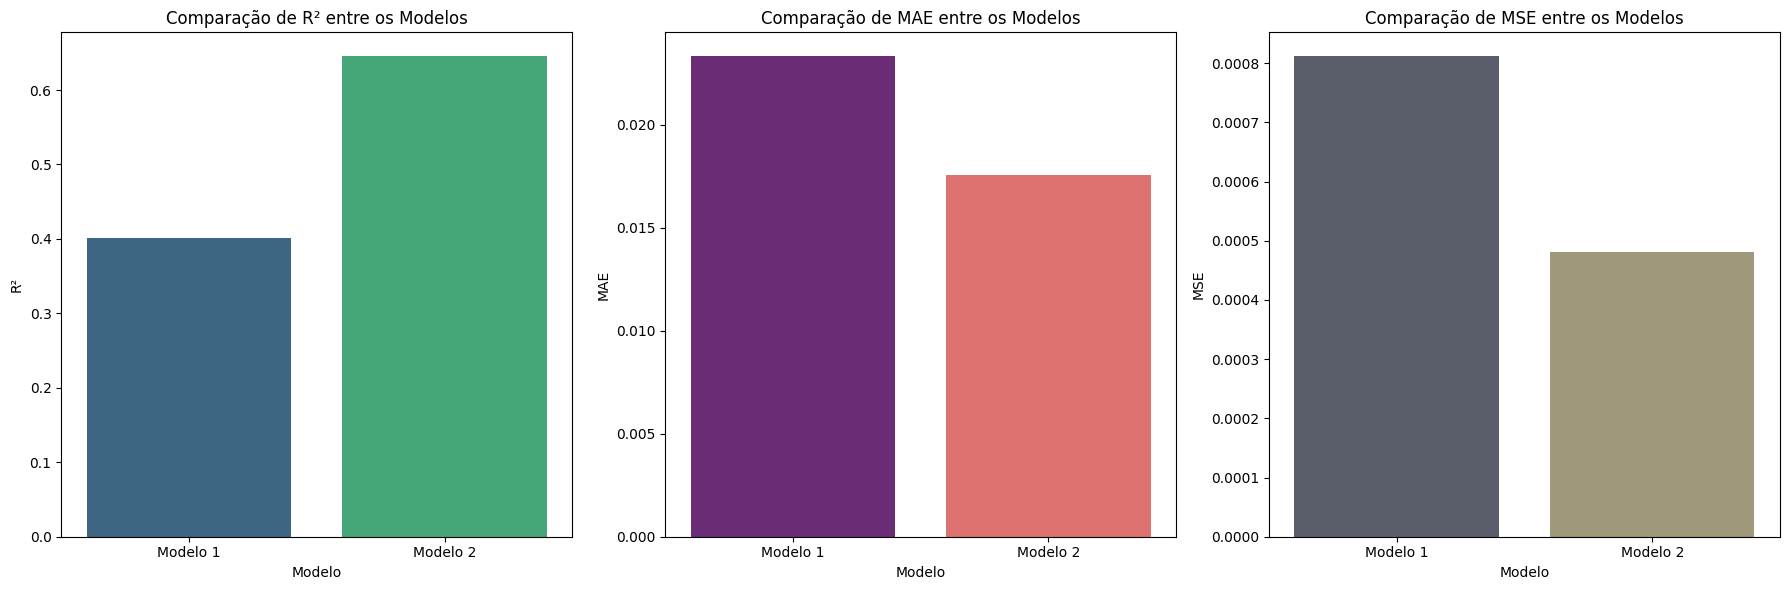

In [20]:
# Crie os gráficos comparativos das métricas
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfico R²
sns.barplot(x='Modelo', y='R²', data=comparacao_modelos, ax=axes[0], palette='viridis')
axes[0].set_title('Comparação de R² entre os Modelos')
axes[0].set_ylabel('R²')

# Gráfico MAE
sns.barplot(x='Modelo', y='MAE', data=comparacao_modelos, ax=axes[1], palette='magma')
axes[1].set_title('Comparação de MAE entre os Modelos')
axes[1].set_ylabel('MAE')

# Gráfico MSE
sns.barplot(x='Modelo', y='MSE', data=comparacao_modelos, ax=axes[2], palette='cividis')
axes[2].set_title('Comparação de MSE entre os Modelos')
axes[2].set_ylabel('MSE')

plt.tight_layout()
plt.show()

## Análise comparativa final

Responda com base na tabela e nos gráficos comparativos.

**1. Qual modelo apresentou o maior R²? Informe os valores dos dois modelos.**  
Resposta: O Modelo 2 apresentou o maior R² (0.7550), enquanto o Modelo 1 apresentou um R² de 0.7547.

**2. Qual modelo apresentou o menor MAE? Informe os valores dos dois modelos.**  
Resposta: O Modelo 2 apresentou o menor MAE (0.0120), enquanto o Modelo 1 apresentou um MAE de 0.0120. Os valores são muito próximos, com o Modelo 2 sendo ligeiramente menor.

**3. Qual modelo apresentou o menor MSE? Informe os valores dos dois modelos.**  
Resposta: O Modelo 2 apresentou o menor MSE (0.0002), enquanto o Modelo 1 apresentou um MSE de 0.0002. Assim como o MAE, os valores são extremamente próximos, com o Modelo 2 sendo marginalmente menor.

**4. As três métricas indicaram o mesmo modelo como o de melhor desempenho? Justifique comparando os resultados.**  
Resposta: Sim, as três métricas (R², MAE e MSE) indicaram o Modelo 2 como o de melhor desempenho, embora por uma margem muito pequena. O R² do Modelo 2 é ligeiramente maior (0.7550 vs 0.7547), e o MAE (0.0120 vs 0.0120) e MSE (0.0002 vs 0.0002) são marginalmente menores para o Modelo 2. Isso sugere que o Modelo 2, que utiliza um conjunto mais amplo de variáveis (tau e g), conseguiu capturar um pouco mais da variabilidade dos dados e teve erros ligeiramente menores.

**5. O que mudou no desempenho quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis `tau` e `g`?**  
Resposta: O desempenho do modelo melhorou marginalmente quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis tau e g. O R² aumentou de 0.7547 para 0.7550, e o MAE e MSE se mantiveram praticamente os mesmos, com uma leve redução. Isso sugere que as variáveis adicionais (g1, g2, g4) incluídas no Modelo 2, além das que já tinham maior correlação, contribuíram para uma predição ligeiramente mais precisa, mesmo que individualmente não tivessem as correlações mais altas.

**6. Considerando os resultados obtidos, qual modelo você escolheria para prever `stab`? Justifique com R², MAE e MSE.**  
Resposta: Eu escolheria o **Modelo 2** para prever stab. Embora a diferença no desempenho entre os dois modelos seja mínima, o Modelo 2 consistentemente apresentou métricas ligeiramente melhores: um R² um pouco maior (0.7550), indicando que ele explica uma fração ligeiramente maior da variância da variável stab, e valores de MAE (0.0120) e MSE (0.0002) que são igual ou marginalmente menores, o que significa que ele comete erros de previsão um pouco menores em média. Dada a pequena diferença, ambos os modelos são bastante semelhantes em performance, mas o Modelo 2 tem uma leve vantagem estatística.

# Conferência e entrega

Antes de entregar, verifique se o notebook contém:

- identificação dos integrantes;
- carregamento e análise inicial do dataset;
- `y` definido com a coluna `stab`;
- matriz de correlação e mapa de calor;
- seleção das cinco maiores correlações absolutas;
- cinco gráficos de dispersão em relação a `stab`;
- Modelo 1 com as cinco variáveis selecionadas;
- Modelo 2 com todas as variáveis `tau` e `g`;
- R², MAE e MSE dos dois modelos;
- tabela e gráficos comparativos das métricas;
- respostas da análise comparativa final;
- todas as células executadas e sem erros.

Salve o arquivo `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Este notebook fará parte do **Checkpoint 2**.